In [1]:
import pickle

# Load features
with open(r'c:\Facultate\CerviAssist\CellsClassification\Results\features_normal_v2.pkl', 'rb') as f:
    features_dict_normal = pickle.load(f)

with open(r'c:\Facultate\CerviAssist\CellsClassification\Results\features_suspecte_v2.pkl', 'rb') as f:
    features_dict_suspecte = pickle.load(f)

features_dict = {**features_dict_normal, **features_dict_suspecte}


In [2]:
all_files = list(features_dict.keys())
all_classes = [file[-12:-4] for file in all_files]

classes = list(set(all_classes))
print(classes)


['o-sq-int', 'z-sq-int', 'z-gl-enc', 'o-gl-enc', 'o-sq-sup', 'z-sq-sup', 'z-sq-baz', 'o-sq-baz']


Features shape: (15405, 1280)
Number of samples: 15405
Classes: ['normal', 'suspecte']
Applying t-SNE...


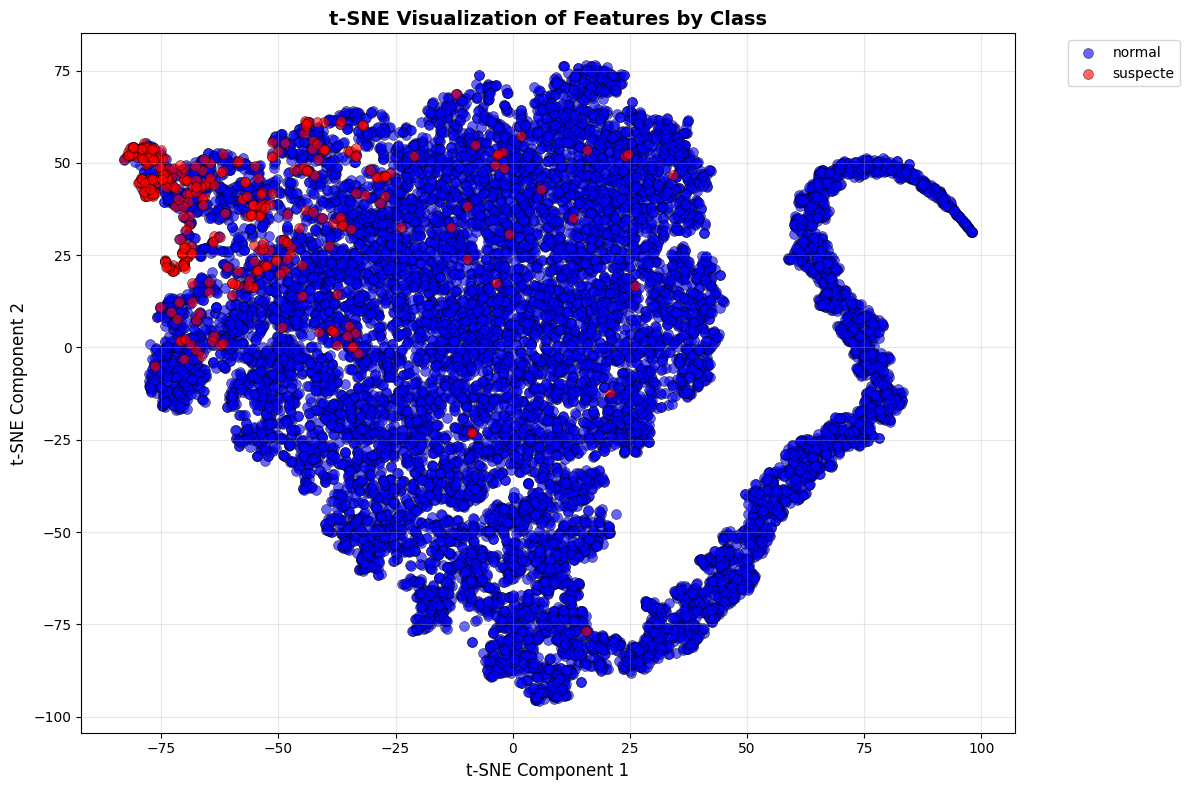

t-SNE visualization complete!


In [3]:
import numpy as np
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# Prepare data for t-SNE
features_list = []
labels_list = []

classes = ['normal', 'suspecte']

for filename, features in features_dict.items():
    # Extract class from filename (last 8 characters before extension)
    class_label = filename[-12:-4]
    class_label = 'suspecte' if class_label[0] == 'z' else 'normal'
    features_list.append(features)
    labels_list.append(class_label)

# Convert to numpy array
X = np.array(features_list)
y = np.array(labels_list)

print(f"Features shape: {X.shape}")
print(f"Number of samples: {len(y)}")
print(f"Classes: {classes}")

# Apply t-SNE
print("Applying t-SNE...")
tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000)
X_tsne = tsne.fit_transform(X)

# Create the plot
plt.figure(figsize=(12, 8))

# Plot each class with a different color
colors = plt.cm.bwr(np.linspace(0, 1, len(classes)))
for idx, class_name in enumerate(classes):
    mask = y == class_name
    plt.scatter(X_tsne[mask, 0], X_tsne[mask, 1], 
                c=[colors[idx]], label=class_name, 
                alpha=0.6, s=50, edgecolors='black', linewidth=0.5)

plt.xlabel('t-SNE Component 1', fontsize=12)
plt.ylabel('t-SNE Component 2', fontsize=12)
plt.title('t-SNE Visualization of Features by Class', fontsize=14, fontweight='bold')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"t-SNE visualization complete!")


In [ ]:
from sklearn.decomposition import PCA

# Apply PCA
print("Applying PCA...")
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)

print(f"Explained variance ratio: {pca.explained_variance_ratio_}")
print(f"Total variance explained: {sum(pca.explained_variance_ratio_):.4f}")

# Create the plot
plt.figure(figsize=(12, 8))

# Plot each class with a different color
colors = plt.cm.bwr(np.linspace(0, 1, len(classes)))
X_pca[:,0] = np.clip(X_pca[:,0], 0, 0.1)
for idx, class_name in enumerate(classes):
    mask = y == class_name
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], 
                c=[colors[idx]], label=class_name, 
                alpha=0.6, s=50, edgecolors='black', linewidth=0.5)

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)', fontsize=12)
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)', fontsize=12)
plt.title('PCA Visualization of Features by Class', fontsize=14, fontweight='bold')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"PCA visualization complete!")


## Label Quality Analysis

This section implements a robust system to identify potentially mislabeled samples using:
1. **Centroid flip score**: measures how close a sample is to the opposite class centroid
2. **k-NN label disagreement**: measures how many neighbors have a different label

The output will be CSV files ranking samples by mislabel likelihood.


In [4]:
import pandas as pd
from sklearn.preprocessing import normalize
from sklearn.neighbors import NearestNeighbors
from sklearn.utils import check_random_state

def prepare(X, y, ids, random_state=42):
    """Prepare data: L2-normalize features for cosine geometry"""
    rs = check_random_state(random_state)
    # L2-normalize for cosine geometry
    Xn = normalize(X, norm='l2')
    y = np.asarray(y)
    ids = np.asarray(ids)
    return Xn, y, ids, rs

def stratified_sample(y, ids, Xn, per_class=100, rs=None):
    """Randomly sample per_class samples from each class"""
    out = {}
    for cls in ["normal", "suspecte"]:
        idx = np.where(y == cls)[0]
        pick = rs.choice(idx, size=min(per_class, len(idx)), replace=False)
        out[cls] = pick
    return out["normal"], out["suspecte"]

def class_centroids(Xn, y):
    """Compute normalized centroids for each class"""
    cent = {}
    for cls in ["normal", "suspecte"]:
        cent[cls] = normalize(Xn[y==cls].mean(axis=0).reshape(1,-1))[0]
    return cent

def centroid_flip_score(Xn, y, cent):
    """
    Compute centroid flip score: how much closer to the other class centroid
    Higher score = more suspicious (closer to the wrong centroid)
    """
    # cosine similarity to each centroid
    Cn = Xn @ cent["normal"]
    Cs = Xn @ cent["suspecte"]
    own = np.where(y=="normal", Cn, Cs)
    other = np.where(y=="normal", Cs, Cn)
    # suspicious if similarity(other) - similarity(own) is large
    return other - own, Cn, Cs

def knn_disagreement(Xn, y, k=30):
    """
    Compute k-NN label disagreement: fraction of neighbors with opposite label
    Also returns distance to nearest opposite-class neighbor
    """
    nn = NearestNeighbors(n_neighbors=min(k+1, len(Xn)), metric="cosine")
    nn.fit(Xn)
    dists, nbrs = nn.kneighbors(Xn, return_distance=True)
    nbrs = nbrs[:,1:]   # drop self
    dists = dists[:,1:]
    ynbr = y[nbrs]
    # fraction of neighbors with the other label
    other = np.where(y=="normal", "suspecte", "normal")
    disagree = (ynbr == other[:,None]).mean(axis=1)
    # nearest distance to any point of the other class (for context)
    mask_other = (ynbr == other[:,None])
    nearest_other_dist = np.where(mask_other, dists, np.inf).min(axis=1)
    return disagree, nearest_other_dist

def z_score(x):
    """Compute z-scores for normalization"""
    m, s = np.nanmean(x), np.nanstd(x) + 1e-12
    return (x - m) / s

print("Label quality analysis functions loaded successfully!")


Label quality analysis functions loaded successfully!


In [6]:
def rank_for_review(Xn, y, ids, idx_subset, cent, k=30):
    """
    Rank a subset of samples by mislabel likelihood
    
    Returns a DataFrame with:
    - id: sample identifier
    - label: assigned label
    - flip_score: centroid flip score
    - knn_disagree: k-NN disagreement rate
    - cos_sim_to_normal: cosine similarity to normal centroid
    - cos_sim_to_suspecte: cosine similarity to suspecte centroid
    - nearest_other_dist: distance to nearest opposite-class sample
    - combined_score: z(flip_score) + z(knn_disagree) - higher = more suspicious
    """
    flip, Cn, Cs = centroid_flip_score(Xn, y, cent)
    disagree, nearest_other_dist = knn_disagreement(Xn, y, k=k)

    sub = idx_subset
    df = pd.DataFrame({
        "id": ids[sub],
        "label": y[sub],
        "flip_score": flip[sub],
        "knn_disagree": disagree[sub],
        "cos_sim_to_normal": Cn[sub],
        "cos_sim_to_suspecte": Cs[sub],
        "nearest_other_dist": nearest_other_dist[sub],
    })
    df["combined_score"] = z_score(df["flip_score"]) + z_score(df["knn_disagree"])
    df = df.sort_values("combined_score", ascending=False).reset_index(drop=True)
    return df

def produce_review_tables(X, y, ids, per_class=100, k=30, random_state=42, save_prefix=""):
    """
    Main function to produce review tables
    
    Args:
        X: feature matrix (N, D)
        y: labels (N,)
        ids: sample identifiers (N,)
        per_class: number of samples to randomly select from each class
        k: number of neighbors for k-NN disagreement
        random_state: random seed for reproducibility
        save_prefix: prefix for output CSV files
    
    Returns:
        df_norm, df_susp: DataFrames with ranked samples for each class
    """
    print(f"Preparing data with {len(X)} samples...")
    Xn, y, ids, rs = prepare(X, y, ids, random_state)
    
    print(f"Sampling {per_class} samples from each class...")
    idx_norm, idx_susp = stratified_sample(y, ids, Xn, per_class, rs)
    
    print("Computing class centroids...")
    cent = class_centroids(Xn, y)
    
    print(f"Ranking samples by mislabel likelihood (k={k})...")
    df_norm = rank_for_review(Xn, y, ids, idx_norm, cent, k=k)
    df_susp = rank_for_review(Xn, y, ids, idx_susp, cent, k=k)
    
    # Save both the random samples and the ranked views
    print(f"Saving results with prefix '{save_prefix}'...")
    pd.DataFrame({"id": ids[idx_norm], "label": y[idx_norm]}).to_csv(
        f"{save_prefix}sample_normals.csv", index=False
    )
    pd.DataFrame({"id": ids[idx_susp], "label": y[idx_susp]}).to_csv(
        f"{save_prefix}sample_suspecte.csv", index=False
    )
    
    df_norm.to_csv(f"{save_prefix}review_candidates_normals_v2.csv", index=False)
    df_susp.to_csv(f"{save_prefix}review_candidates_suspecte_v2.csv", index=False)
    
    print("\n✓ Analysis complete! Files saved:")
    print(f"  - {save_prefix}sample_normals_v2.csv")
    print(f"  - {save_prefix}sample_suspecte_v2.csv")
    print(f"  - {save_prefix}review_candidates_normals_v2.csv")
    print(f"  - {save_prefix}review_candidates_suspecte_v2.csv")
    
    return df_norm, df_susp

print("Main analysis function loaded successfully!")


Main analysis function loaded successfully!


In [7]:
# Prepare IDs from the features_dict keys
ids = np.array(list(features_dict.keys()))

# Run the analysis
df_norm, df_susp = produce_review_tables(
    X=X, 
    y=y, 
    ids=ids, 
    per_class=100,  # Sample 100 from each class
    k=30,           # Use 30 nearest neighbors
    random_state=42,
    save_prefix=""  # No prefix, saves directly to current directory
)

print("\n" + "="*60)
print("Analysis Summary")
print("="*60)
print(f"\nTotal samples analyzed: {len(X)}")
print(f"  - Normal: {(y=='normal').sum()}")
print(f"  - Suspecte: {(y=='suspecte').sum()}")
print(f"\nSamples per class for review: 100")
print(f"k-NN neighbors used: 30")


Preparing data with 15405 samples...
Sampling 100 samples from each class...
Computing class centroids...
Ranking samples by mislabel likelihood (k=30)...
Saving results with prefix ''...

✓ Analysis complete! Files saved:
  - sample_normals_v2.csv
  - sample_suspecte_v2.csv
  - review_candidates_normals_v2.csv
  - review_candidates_suspecte_v2.csv

Analysis Summary

Total samples analyzed: 15405
  - Normal: 15020
  - Suspecte: 385

Samples per class for review: 100
k-NN neighbors used: 30


In [8]:
# Display top 20 most suspicious samples from each class

print("="*80)
print("TOP 20 MOST SUSPICIOUS 'NORMAL' SAMPLES")
print("="*80)
print("\nThese samples are labeled 'normal' but have characteristics of 'suspecte':\n")
print(df_norm.head(20).to_string(index=True))

print("\n\n" + "="*80)
print("TOP 20 MOST SUSPICIOUS 'SUSPECTE' SAMPLES")
print("="*80)
print("\nThese samples are labeled 'suspecte' but have characteristics of 'normal':\n")
print(df_susp.head(20).to_string(index=True))

print("\n\n" + "="*80)
print("INTERPRETATION GUIDE")
print("="*80)
print("""
Columns explained:
- combined_score: Overall suspicion score (higher = more likely mislabeled)
- flip_score: How much closer to the OTHER class centroid (positive = suspicious)
- knn_disagree: Fraction of k-NN neighbors with the opposite label (0-1 range)
- cos_sim_to_normal: Cosine similarity to 'normal' centroid
- cos_sim_to_suspecte: Cosine similarity to 'suspecte' centroid
- nearest_other_dist: Distance to nearest opposite-class sample (lower = more suspicious)

Review strategy:
1. Start with the top 20 samples (highest combined_score)
2. Sample a few mid-range scores (around row 50)
3. Check a few low scores (around row 90) as sanity check
""")


TOP 20 MOST SUSPICIOUS 'NORMAL' SAMPLES

These samples are labeled 'normal' but have characteristics of 'suspecte':

                           id   label  flip_score  knn_disagree  cos_sim_to_normal  cos_sim_to_suspecte  nearest_other_dist  combined_score
0     61857_5_6_no-sq-baz.jpg  normal    0.098708      0.366667           0.881726             0.980434            0.006787        9.740385
1    67552_19_8_no-sq-baz.jpg  normal    0.054123      0.166667           0.933159             0.987282            0.011235        4.692181
2    69925_15_6_no-sq-baz.jpg  normal    0.043374      0.133333           0.944960             0.988335            0.007118        3.818607
3     54641_6_9_no-sq-int.jpg  normal    0.066103      0.066667           0.907203             0.973306            0.018567        2.500788
4     62079_3_7_no-sq-int.jpg  normal    0.052956      0.066667           0.906275             0.959230            0.026537        2.373157
5     62079_6_9_no-sq-int.jpg  normal    0.

In [9]:
# save the results as csv
df_norm.to_csv(r"c:\Facultate\CerviAssist\CellsClassification\Results\review_candidates_normals_v2.csv", index=False)
df_susp.to_csv(r"c:\Facultate\CerviAssist\CellsClassification\Results\review_candidates_suspecte_v2.csv", index=False)

In [12]:
path = r'c:\Facultate\CerviAssist\CellsClassification\Dataset\2025_11_13\raw_sante\suspecte'
files = ['60142_13_1_dz-sq-baz.jpg', '60024_20_1_dz-gl-enc.jpg', '67888_15_2_dz-sq-baz.jpg', '55192_15_3_dz-sq-baz.jpg', '55192_32_4_dz-sq-baz.jpg', '55192_19_10_dz-sq-baz.jpg', '63942_1_1_dz-gl-enc.jpg', '55192_15_11_dz-sq-baz.jpg', '53823_7_2_dz-sq-int.jpg', '60024_20_2_dz-gl-enc.jpg', '60197_5_7_dz-sq-int.jpg', '63942_6_7_dz-gl-enc.jpg', '59337_1_5_dz-sq-int.jpg', '61570_18_7_dz-sq-baz.jpg', '61570_18_6_dz-sq-baz.jpg', '55192_16_2_dz-sq-baz.jpg', '64667_12_1_dz-sq-baz.jpg', '61570_18_5_dz-sq-baz.jpg', '69077_2_7_dz-gl-enc.jpg', '59316_9_7_dz-sq-int.jpg', '7468_10_6_dz-sq-baz.jpg', '7468_17_3_dz-sq-baz.jpg', '7468_20_8_dz-sq-baz.jpg', '68266_7_1_dz-sq-baz.jpg', '4656_2_4_dz-sq-baz.jpg', '7468_17_7_dz-sq-baz.jpg', '7468_25_5_dz-sq-baz.jpg', '7468_13_13_dz-sq-baz.jpg', '68266_9_3_dz-sq-baz.jpg', '7468_18_7_dz-sq-baz.jpg']
destination = r'c:\Facultate\CerviAssist\CellsClassification\Dataset\2025_11_03\all\__problematice2\suspecte'

# copy the files from list to destination
import os
import shutil

os.makedirs(destination, exist_ok=True)

for file in files:
    src = os.path.join(path, file)
    dst = os.path.join(destination, file)
    try:
        shutil.copy2(src, dst)
        print(f"Copied {src} -> {dst}")
    except Exception as e:
        print(f"Failed to copy {src}: {e}")


Copied c:\Facultate\CerviAssist\CellsClassification\Dataset\2025_11_13\raw_sante\suspecte\60142_13_1_dz-sq-baz.jpg -> c:\Facultate\CerviAssist\CellsClassification\Dataset\2025_11_03\all\__problematice2\suspecte\60142_13_1_dz-sq-baz.jpg
Copied c:\Facultate\CerviAssist\CellsClassification\Dataset\2025_11_13\raw_sante\suspecte\60024_20_1_dz-gl-enc.jpg -> c:\Facultate\CerviAssist\CellsClassification\Dataset\2025_11_03\all\__problematice2\suspecte\60024_20_1_dz-gl-enc.jpg
Copied c:\Facultate\CerviAssist\CellsClassification\Dataset\2025_11_13\raw_sante\suspecte\67888_15_2_dz-sq-baz.jpg -> c:\Facultate\CerviAssist\CellsClassification\Dataset\2025_11_03\all\__problematice2\suspecte\67888_15_2_dz-sq-baz.jpg
Copied c:\Facultate\CerviAssist\CellsClassification\Dataset\2025_11_13\raw_sante\suspecte\55192_15_3_dz-sq-baz.jpg -> c:\Facultate\CerviAssist\CellsClassification\Dataset\2025_11_03\all\__problematice2\suspecte\55192_15_3_dz-sq-baz.jpg
Copied c:\Facultate\CerviAssist\CellsClassification\Data

In [17]:
source = r"c:\Facultate\CerviAssist\Segmentare\Dataset\FullDatasetTablou_2025_11_13"
destination = r"c:\Facultate\CerviAssist\Segmentare\Dataset\Selected"

import os
import shutil
import random

# Ensure destination exists
os.makedirs(destination, exist_ok=True)

# Iterate through each sub-folder in the source
for subfolder_name in os.listdir(source):
    subfolder_path = os.path.join(source, subfolder_name)
    if os.path.isdir(subfolder_path):
        # Find all .jpg files in subfolder (paired with .xml)
        jpg_files = [f for f in os.listdir(subfolder_path) if f.lower().endswith('.jpg')]
        # Only keep those for which a matching .xml exists
        paired_files = [f for f in jpg_files if os.path.exists(os.path.join(subfolder_path, os.path.splitext(f)[0] + '.xml'))]
        if paired_files:
            chosen_file = paired_files[0]
            jpg_src = os.path.join(subfolder_path, chosen_file)
            xml_src = os.path.join(subfolder_path, os.path.splitext(chosen_file)[0] + '.xml')
            # Copy .jpg and .xml to destination, maybe prefix with subfolder to avoid collisions
            jpg_dst = os.path.join(destination, f"{chosen_file}")
            xml_dst = os.path.join(destination, f"{os.path.splitext(chosen_file)[0]}.xml")
            try:
                shutil.copy2(jpg_src, jpg_dst)
                shutil.copy2(xml_src, xml_dst)
                print(f"Copied {jpg_src} and {xml_src} to {destination}")
            except Exception as e:
                print(f"Failed to copy files from {subfolder_path}: {e}")
        else:
            print(f"No paired .jpg/.xml files in {subfolder_path}")


Copied c:\Facultate\CerviAssist\Segmentare\Dataset\FullDatasetTablou_2025_11_13\00\00_1.jpg and c:\Facultate\CerviAssist\Segmentare\Dataset\FullDatasetTablou_2025_11_13\00\00_1.xml to c:\Facultate\CerviAssist\Segmentare\Dataset\Selected
Copied c:\Facultate\CerviAssist\Segmentare\Dataset\FullDatasetTablou_2025_11_13\2025\2025_1.jpg and c:\Facultate\CerviAssist\Segmentare\Dataset\FullDatasetTablou_2025_11_13\2025\2025_1.xml to c:\Facultate\CerviAssist\Segmentare\Dataset\Selected
Copied c:\Facultate\CerviAssist\Segmentare\Dataset\FullDatasetTablou_2025_11_13\4656\4656_1.jpg and c:\Facultate\CerviAssist\Segmentare\Dataset\FullDatasetTablou_2025_11_13\4656\4656_1.xml to c:\Facultate\CerviAssist\Segmentare\Dataset\Selected
Copied c:\Facultate\CerviAssist\Segmentare\Dataset\FullDatasetTablou_2025_11_13\48063\48063_1.jpg and c:\Facultate\CerviAssist\Segmentare\Dataset\FullDatasetTablou_2025_11_13\48063\48063_1.xml to c:\Facultate\CerviAssist\Segmentare\Dataset\Selected
Copied c:\Facultate\Cerv